# Analysis for the CBW inputs received in 2026-Q1

In [15]:
from heeps.config.read_config import read_config
from heeps.config.update_config import update_config
from heeps.util.img_processing import resize_cube
from heeps.util.freq_decomp import conv_kernel, spatial
from astropy.io import fits
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline

# Load NCPAs and masks

In [16]:
os.chdir(os.path.normpath(os.path.expandvars('$HOME/heeps_metis/input_files')))
folder = 'wavefront/cbw/20260127'
filename = os.path.join(folder, '%s/%s_rep_%s_field_%s.fits.gz')
tag = {'L':'L', 'N2':'N2'}
# start_frames = [0, 13, 25, 32, 44 ]
# start_times =['-2h00','-1h30','-1h00','-0h45','-0h15']
start_frames = [0]
start_times =['-0h30']
npupil_L = update_config(**dict(read_config(), band='L'))['npupil']
npupil_N = update_config(**dict(read_config(), band='N2'))['npupil']
npupil = {'L':npupil_L, 'N2':npupil_N}
scao_date = '2026'
scao_cube = {'L':fits.getdata('wavefront/dfull/2026_grid/cube_Dfull_%s_Q2_3600_100ms_Kmag6_0piston_meters_scao_only_%s.fits'%(scao_date, npupil_L)),
           'N2':fits.getdata('wavefront/dfull/2026_grid/cube_Dfull_%s_Q2_3600_100ms_Kmag6_0piston_meters_scao_only_%s.fits'%(scao_date, npupil_N))}
mask_L = fits.getdata('wavefront/dfull/mask4heeps_Telescope_Pupil_%s.fits'%(npupil_L)) > 0.5
mask_N = fits.getdata('wavefront/dfull/mask4heeps_Telescope_Pupil_%s.fits'%(npupil_N)) > 0.5
mask = {'L':mask_L, 'N2':mask_N}
# mask_M1 = fits.getdata('pupil/eso/mask_M1_511.fits') > 0.5
# plt.imshow(mask_M1, origin='lower');


   Auto-selection Lyot stop from definition



   Auto-selection Lyot stop from definition
   [ WARNING ] no file for auto-select Lyot stop not found at /home/gorban/heeps_metis/input_files/




# Simplified function to run on the reformatted NCPA sequences

Shape cbw = (12000, 119, 119)
Shape cbw = (25, 119, 119)
9.225652e-09 1.0313887e-07


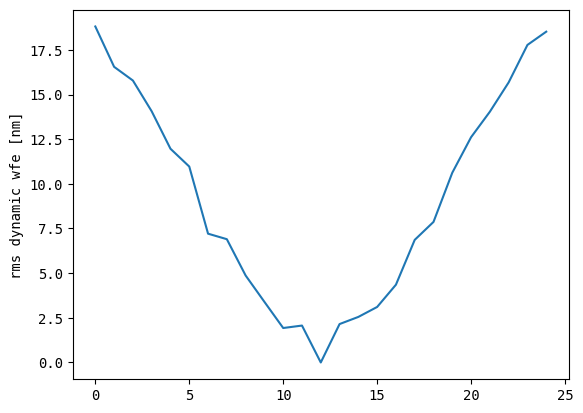

In [31]:
band='N2'
npupil={'N2' : 119, 'L': 285}
cbw = fits.getdata(f'wavefront/cbw/20260127/ncpa/{band}_rep_1.fits')[::18]
pup = fits.getdata(f'wavefront/dfull/mask4heeps_Telescope_Pupil_{npupil[band]}.fits') > 0.5

cbw = fits.getdata(f'wavefront/cbw/20221006/ncpa/N_rep_5_-0h30.fits')
print(f'Shape cbw = {cbw.shape}')
cbw = cbw[::480]
print(f'Shape cbw = {cbw.shape}')
# pup = fits.getdata(f'wavefront/cbw/mask_Cfull_20220929_N2_{npupil[band]}.fits') >= 0.5

wf_middle = cbw[cbw.shape[0]//2]

rms_dyn = np.std((cbw - wf_middle)[:, pup], axis=1)
rms = np.std((cbw )[:, pup], axis=1)

print(np.mean(rms_dyn), np.mean(rms))

plt.figure()
plt.plot(rms_dyn*1e9)
# plt.plot((np.arange(2000)*1.8 -1800)/60, rms_dyn*1e9)
# plt.xlabel('minutes')
plt.ylabel('rms dynamic wfe [nm]')
plt.show()

# plt.figure()
# plt.plot((np.arange(2000)*1.8 -1800)/60, rms*1e9)
# plt.xlabel('minutes')
# plt.ylabel('rms dynamic wfe [nm]')
# plt.show()

1.0467734e-07


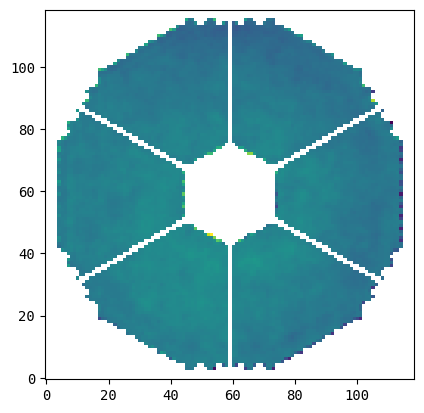

In [20]:
cbw1 = cbw[0]
cbw1[pup==0] = np.nan

print(np.std(cbw1[pup==1]))
plt.figure()
plt.imshow(cbw1)
plt.show()

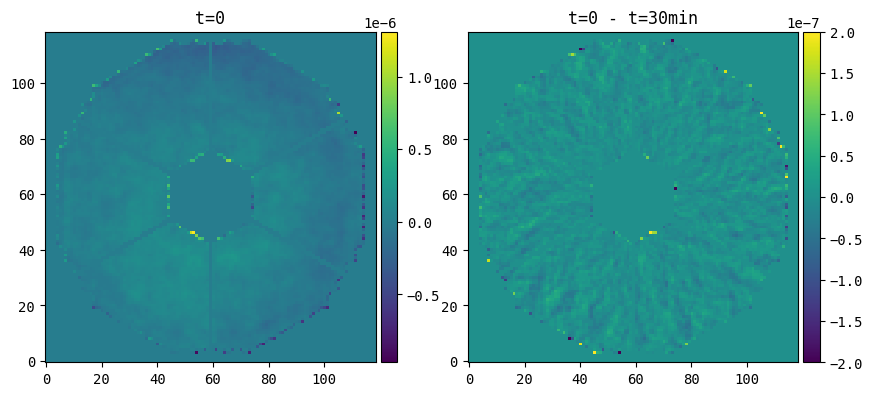

In [32]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

im1 = ax1.imshow(cbw[0])
ax1.set_title('t=0')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im1, cax=cax1)

im2 = ax2.imshow(cbw[0] - wf_middle, vmin=-2e-7, vmax=2e-7)
ax2.set_title('t=0 - t=30min')
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im2, cax=cax2)

plt.show()

## Spatial frequency analysis

(11, 11)
rms(all SF) = 53.20 nm
rms(LSF) = 48.87 nm
rms(HSF) = 18.79 nm


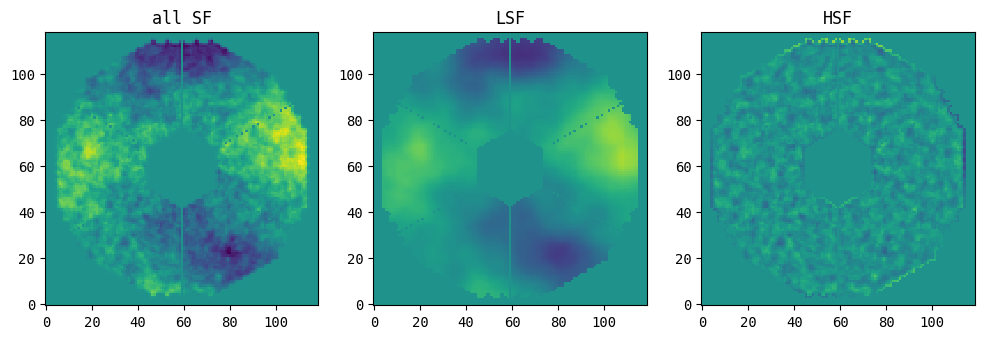

In [30]:
def spatial_filter(ncpa, pup_mask, cpp=10, nimg=511):
    pupil_img_size = 39.9988
    diam_nominal = 38.542
    nkernel = nimg*diam_nominal/pupil_img_size
    kernel = conv_kernel(nkernel, cpp)
    print(kernel.shape)
    # ncpa = DIFF(band, rep, field)*1e9
    allSF, LSF, HSF = spatial(ncpa*pup_mask, kernel, norm=False, verbose=True)

    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,4))
    plt.subplot(131); plt.title('all SF')
    im = plt.imshow(allSF*pup_mask, origin='lower')
    vmin, vmax = plt.gci().get_clim()
    plt.subplot(132); plt.title('LSF')
    plt.imshow(LSF*pup_mask, origin='lower', vmin=vmin, vmax=vmax)
    plt.subplot(133); plt.title('HSF')
    plt.imshow(HSF*pup_mask, origin='lower', vmin=vmin, vmax=vmax);
    plt.show()

    return allSF, LSF, HSF


allSF, LSF, HSF = spatial_filter(np.mean(cbw, axis=0)*1e9, pup, nimg=npupil[band])

4.8871705e-08 1.878699e-08


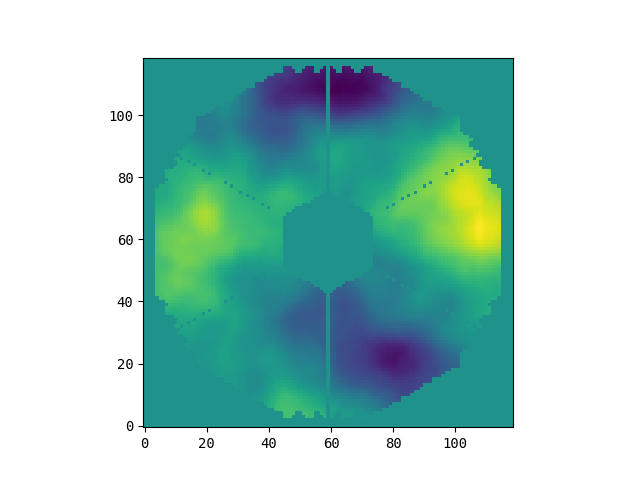

In [42]:
print(np.nanstd(LSF[pup==1]), np.std(HSF[pup==1]))
%matplotlib widget
plt.figure()
plt.imshow(LSF)
# plt.show()

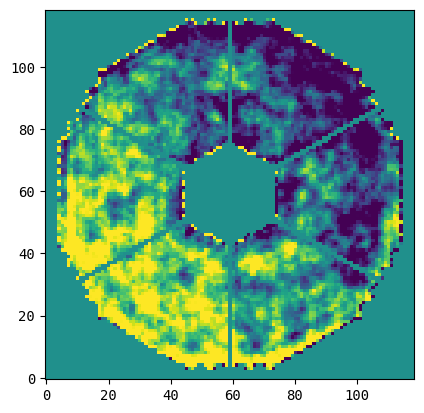

7.764428e-08


In [12]:
ddir = '/home/gorban/heeps_metis/input_files/wavefront/dfull/'
f_phase = '2026_grid/cube_Dfull_2026_Q2_3600_100ms_Kmag6_N2_scao+cbw_no_noise_lag0_gain1_119.fits'
# f_phase = '2026_grid/cube_Dfull_2026_Q2_3600_100ms_Kmag6_N2_scao+wv_no_noise_lag0_gain1_119.fits'
pup = fits.getdata(ddir + 'mask4heeps_Telescope_Pupil_119.fits')>=0.5

ddir = '/home/gorban/heeps_metis/input_files/wavefront/cfull/'
f_phase = 'cube_Cfull_20250119_3600s_300ms_nzer_20_cbw_ncpa_N2_119.fits'
pup = fits.getdata(ddir + 'mask_Cfull_20220929_N2_119.fits') >= 0.5

cube = fits.getdata(ddir + f_phase)
mcube = np.mean(cube, axis=0)


plt.figure()
plt.imshow(mcube*pup*1e9, vmin=-75, vmax=75)
plt.show()

print(np.std(mcube[pup]))